In [1]:
import tensorflow as tf
import keras
from keras import layers
import numpy as np

# Load Fashion MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

c = len(set(y_train))  # number of classes

# Scale pixels to [0, 1]
x_train = x_train.astype("float32") / 255
x_test  = x_test.astype("float32") / 255

# Add channel dimension
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)
dim = x_train.shape[1:]

# One-hot encode labels
y_train = keras.utils.to_categorical(y_train, c)
y_test  = keras.utils.to_categorical(y_test, c)

# Build CNN
cnn = keras.Sequential(name="fashion_mnist_cnn_model")
cnn.add(layers.Input(dim, name="input_layer"))
cnn.add(layers.Conv2D(8, kernel_size=(3, 3), activation="relu"))
cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))
cnn.add(layers.Conv2D(12, kernel_size=(3, 3), activation="relu"))
cnn.add(layers.MaxPooling2D(pool_size=(2, 2)))
cnn.add(layers.Flatten(name="flatten_2d_to_1d"))
cnn.add(layers.Dropout(0.5, name="final_drop_out"))
cnn.add(layers.Dense(c, activation="softmax", name="final_output"))

cnn.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.SGD(learning_rate=1e-2),
    metrics=["accuracy"]
)

cnn.build()
cnn.summary()

history = cnn.fit(
    x=x_train,
    y=y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.5
)

pred_prob = cnn.predict(x_test)
y_l = np.argmax(y_test, axis=1)
p_l = np.argmax(pred_prob, axis=1)
test_accuracy = np.mean(y_l == p_l)
print("Test accuracy:", test_accuracy)

2026-04-06 13:25:35.116606: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "fashion_mnist_cnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 12)     │           876 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 12)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2d_to_1d (Flatten)      │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_drop_out (Dropout)        │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_output (Dense)            │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,966 (15.49 KB)

 Trainable params: 3,966 (15.49 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4700 - loss: 1.4631 - val_accuracy: 0.7222 - val_loss: 0.7976
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.6894 - loss: 0.8533 - val_accuracy: 0.7638 - val_loss: 0.6583
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.7265 - loss: 0.7404 - val_accuracy: 0.7873 - val_loss: 0.5975
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.7461 - loss: 0.6912 - val_accuracy: 0.7886 - val_loss: 0.5680
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7601 - loss: 0.6547 - val_accuracy: 0.8011 - val_loss: 0.5494
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7694 - loss: 0.6270 - val_accuracy: 0.8088 - val_loss: 0.5193
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.7740 - loss: 0.6108 - val_accuracy: 0.8211 - val_loss: 0.4972
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.7828 - loss: 0.5891 - v

Epoch 1/10


/Users/teddytaussig/COM328_tf/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7062 - auc: 0.9638 - loss: 0.8020 - val_accuracy: 0.8114 - val_auc: 0.9849 - val_loss: 0.5090
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7939 - auc: 0.9807 - loss: 0.5663 - val_accuracy: 0.8352 - val_auc: 0.9875 - val_loss: 0.4646
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.8101 - auc: 0.9831 - loss: 0.5272 - val_accuracy: 0.8466 - val_auc: 0.9887 - val_loss: 0.4459
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.8171 - auc: 0.9842 - loss: 0.5052 - val_accuracy: 0.8528 - val_auc: 0.9890 - val_loss: 0.4234
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.8248 - auc: 0.9853 - loss: 0.4881 - val_accuracy: 0.8588 - val_auc: 0.9900 - val_loss: 0.4047
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.8305 - auc: 0.9859 - loss: 0.4751 - val_accuracy: 0.8615 - val_auc: 0.9906 - val_loss: 0.3956
Epoch 7/10
1500/1500 ━━━━━━

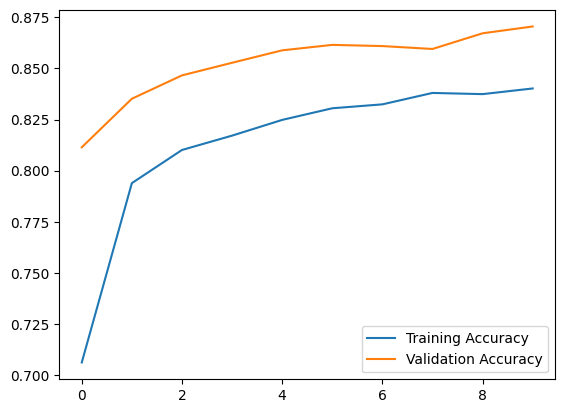

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load Fashion MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

num_classes = len(set(y_train))

# Convert labels to categorical
y_train = keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes=num_classes)

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Define CNN model
model = keras.Sequential([
    layers.Conv2D(8, (3, 3), activation="relu", input_shape=x_train.shape[1:]),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(12, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

# Compile model
model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy", keras.metrics.AUC()]
)

# Train model
history = model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2
)

# Evaluate model
test_loss, test_acc, test_auc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.2f}")
print(f"Test AUC: {test_auc:.2f}")

# Plot training and validation accuracy
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.show()